In [1]:
import os
import optuna
import pandas as pd

# dataflg = 'noaa'
dataflg = 'era5'
model_name = 'UNet_A'
# model_name = 'CNN_MLP'
study_id = 1

input_vars = ['olr',]
# input_vars = ['olr', 'tcwv', 'u200', 'u850', 'prep', 'sst',
#  'u500', 'q200', 'q500', 'q850', 'T200', 'T500', 'T850',
#   'v200', 'v500', 'v850', 'Z200', 'Z500', 'Z850']

expflgs = [
    'unscaled_m10all_wnx1off_c20', 
    'unscaled_m10all_wnx9all_c20',
    'unscaled_m10resi_wnx9resi_c20'
]
output_vars = ['ROMI', 'RMM']
# output_vars = ['ROMI',]

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/SENS/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for outvar in output_vars:
    for exp in expflgs:
        for invar in input_vars:
            exp_name = f"{dataflg}_{invar}_{model_name}_{outvar}_{exp}_s{study_id}"
            db_path = os.path.join(optuna_dir, f"{exp_name}.db")
            
            if os.path.exists(db_path):
                try:
                    study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                    
                    # Check if there are any completed trials to avoid errors
                    if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                        best_val = f"{study.best_value:.6f}"
                        best_params = study.best_params # This is the dictionary you want
                    else:
                        best_val = "N/A"
                        best_params = "No completed trials"
                        
                    print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                
                except Exception:
                    print(f"{exp_name[:60]:<60} | Error    | Failed to load")
            else:
                print(f"not existing: {exp_name}")
                pass 


/home/users/linyao/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_olr_UNet_A_ROMI_unscaled_m10all_wnx1off_c20_s1          | 100      | 0.520217     | {'norm_type': 'group', 'num_filters_enc': 64, 'kernel_size': 9, 'nhidden1': 512, 'nhidden2': 64, 'nhidden3': 80, 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'learning_rate': 0.004041426185026052, 'weight_decay': 0.00011261127190386491, 'batch_size': 64}
era5_olr_UNet_A_ROMI_unscaled_m10all_wnx9all_c20_s1          | 100      | 0.522994     | {'norm_type': 'group', 'num_filters_enc': 48, 'kernel_size': 9, 'nhidden1': 512, 'nhidden2': 192, 'nhidden3': 32, 'dropout_rate': 0.5, 'optimizer': 'AdamW', 'learning_rate': 0.0002825550368450077, 'weight_decay': 0.00035623758539379954, 'batch_size': 32}
era5_olr_UNet_A_ROMI_unscaled_m10resi_wnx9resi_c20_s1        | 100      | 0.565872 

In [3]:
import os
import optuna
import pandas as pd

# dataflg = 'noaa'
dataflg = 'era5'
model_name = 'UNet_A'
# model_name = 'CNN_MLP'
study_id = 1

input_vars = ['olr',]
# input_vars = ['olr', 'tcwv', 'u200', 'u850', 'prep', 'sst',
#  'u500', 'q200', 'q500', 'q850', 'T200', 'T500', 'T850',
#   'v200', 'v500', 'v850', 'Z200', 'Z500', 'Z850']

expflgs = [
    'fltano120', 
    'rescaled_m10all_wnx1off', 
    'unscaled_m10all_wnx1off', 
    'rescaled_m10all_wnx9all', 
    'unscaled_m10all_wnx9all', 
    'rescaled_m10resi_wnx9resi', 
    'unscaled_m10resi_wnx9resi'
]
output_vars = ['RMM', 'ROMI']
lead = 25
# output_vars = ['RMM',]
# lead = 15

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/MD/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for lead in range(0,40,5):
    for outvar in output_vars:
        for exp in expflgs:
            for invar in input_vars:
                exp_name = f"{dataflg}_{invar}_{model_name}_{outvar}_{exp}_lead{lead}_s{study_id}"
                db_path = os.path.join(optuna_dir, f"{exp_name}.db")
                
                if os.path.exists(db_path):
                    try:
                        study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                        
                        # Check if there are any completed trials to avoid errors
                        if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                            best_val = f"{study.best_value:.6f}"
                            best_params = study.best_params # This is the dictionary you want
                        else:
                            best_val = "N/A"
                            best_params = "No completed trials"
                            
                        print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                    
                    except Exception:
                        print(f"{exp_name[:60]:<60} | Error    | Failed to load")
                else:
                    print(f"not existing: {exp_name}")
                    pass 


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_olr_UNet_A_RMM_fltano120_lead0_s1                       | 100      | 0.208472     | {'norm_type': 'batch', 'num_filters_enc': 48, 'kernel_size': 3, 'nhidden1': 512, 'nhidden2': 256, 'nhidden3': 48, 'dropout_rate': 0.1, 'optimizer': 'AdamW', 'learning_rate': 0.00012119496207894149, 'weight_decay': 0.00010799876820795435, 'batch_size': 48}
era5_olr_UNet_A_RMM_rescaled_m10all_wnx1off_lead0_s1         | 100      | 0.229633     | {'norm_type': 'batch', 'num_filters_enc': 16, 'kernel_size': 3, 'nhidden1': 256, 'nhidden2': 128, 'nhidden3': 128, 'dropout_rate': 0.2, 'optimizer': 'AdamW', 'learning_rate': 0.0014061609600029019, 'weight_decay': 0.001024640739293632, 'batch_size': 32}
era5_olr_UNet_A_RMM_unscaled_m10all_wnx1off_lead0_s1         | 100      | 0.22443

--- Hyperparameter Importance for era5_olr_UNet_A_RMM_fltano120_s1 ---
optimizer                : 0.2384 (23.8%)
nhidden2                 : 0.2011 (20.1%)
nhidden3                 : 0.1700 (17.0%)
num_filters_enc          : 0.1698 (17.0%)
dropout_rate             : 0.1252 (12.5%)
batch_size               : 0.0477 (4.8%)
nhidden1                 : 0.0382 (3.8%)
kernel_size              : 0.0070 (0.7%)
norm_type                : 0.0025 (0.2%)


/tmp/ipykernel_6446/2173300368.py:21: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


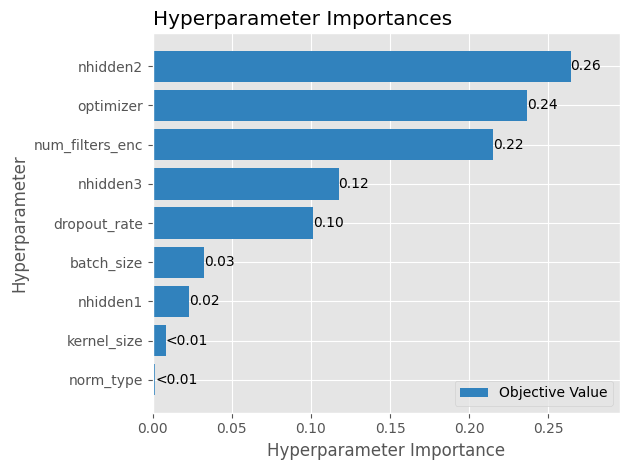

In [7]:
import os
import optuna
import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as ovm

exp_name = "era5_olr_UNet_A_RMM_fltano120_s1"
storage = f"sqlite:////scratch/users/linyao/ML4MJO/scripts/exp/MD/optuna/{exp_name}.db"

# 1. Load Study
study = optuna.load_study(study_name=exp_name, storage=storage)

# 2. Corrected Function Name: get_param_importances (with an 's')
importance = optuna.importance.get_param_importances(study)

print(f"--- Hyperparameter Importance for {exp_name} ---")
for param, val in importance.items():
    print(f"{param:<25}: {val:.4f} ({val*100:.1f}%)")

# 3. Matplotlib-based Plots (to avoid Plotly requirement)
# Importance Plot
ovm.plot_param_importances(study)
# plt.title(f"Importance: {exp_name}")
plt.tight_layout()
plt.show()



In [1]:
import os
import optuna
import pandas as pd

dataflg = 'era5'
model_name = 'UNet_A'
# model_name = 'CNN_MLP'
study_id = 1

input_vars = ['olr', 'tcwv', 'u200', 'u850', 'prep','sst','u200','q200','q850','q500','T200','T500','T850','Z200','Z500','Z850','v200','v500','v850']
expflgs = [
    'fltano120', 
]
output_vars = ['ROMI', 'RMM']
# output_vars = ['RMM',]

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/MD/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for outvar in output_vars:
    for exp in expflgs:
        for invar in input_vars:
            exp_name = f"{dataflg}_{invar}_{model_name}_{outvar}_{exp}_s{study_id}"
            db_path = os.path.join(optuna_dir, f"{exp_name}.db")
            
            if os.path.exists(db_path):
                try:
                    study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                    
                    # Check if there are any completed trials to avoid errors
                    if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                        best_val = f"{study.best_value:.6f}"
                        best_params = study.best_params # This is the dictionary you want
                    else:
                        best_val = "N/A"
                        best_params = "No completed trials"
                        
                    print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                
                except Exception:
                    print(f"{exp_name[:60]:<60} | Error    | Failed to load")
            else:
                print(f"not existing: {exp_name}")
                pass 


/home/users/linyao/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_olr_UNet_A_ROMI_fltano120_s1                            | 100      | 0.512807     | {'norm_type': 'batch', 'num_filters_enc': 48, 'kernel_size': 9, 'nhidden1': 384, 'nhidden2': 64, 'nhidden3': 128, 'dropout_rate': 0.4, 'optimizer': 'SGD', 'learning_rate': 0.12202684716606452, 'weight_decay': 2.942717430065119e-05, 'momentum': 0.8500000000000001, 'batch_size': 48}
era5_tcwv_UNet_A_ROMI_fltano120_s1                           | 100      | 0.537507     | {'norm_type': 'batch', 'num_filters_enc': 32, 'kernel_size': 5, 'nhidden1': 384, 'nhidden2': 192, 'nhidden3': 48, 'dropout_rate': 0.5, 'optimizer': 'SGD', 'learning_rate': 0.01155407860398607, 'weight_decay': 3.1562766730342025e-05, 'momentum': 0.9, 'batch_size': 64}
era5_u200_UNet_A_ROMI_fltano120_s1       

In [2]:
import os
import optuna
import pandas as pd

dataflg = 'era5'
model_name = 'UNet_A'
study_id = 1

input_vars = ['olr', 'tcwv', 'u200', 'u850', 'prep','sst','u200','q200','q850','q500','T200','T500','T850','Z200','Z500','Z850','v200','v500','v850']
expflgs = [
    'fltano120', 
]
output_vars = ['RMM','ROMI']
# output_vars = ['RMM',]

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/MD/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for outvar in output_vars:
    if outvar == 'RMM':
        lead = 15
    else:
        lead = 25
    for exp in expflgs:
        for invar in input_vars:
            exp_name = f"{dataflg}_{invar}_{model_name}_{outvar}_{exp}_lead{lead}_s{study_id}"
            db_path = os.path.join(optuna_dir, f"{exp_name}.db")
            
            if os.path.exists(db_path):
                try:
                    study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                    
                    # Check if there are any completed trials to avoid errors
                    if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                        best_val = f"{study.best_value:.6f}"
                        best_params = study.best_params # This is the dictionary you want
                    else:
                        best_val = "N/A"
                        best_params = "No completed trials"
                        
                    print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                
                except Exception:
                    print(f"{exp_name[:60]:<60} | Error    | Failed to load")
            else:
                print(f"not existing: {exp_name}")
                pass 


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_olr_UNet_A_RMM_fltano120_lead15_s1                      | 100      | 0.768744     | {'norm_type': 'batch', 'num_filters_enc': 48, 'kernel_size': 7, 'nhidden1': 128, 'nhidden2': 64, 'nhidden3': 80, 'dropout_rate': 0.1, 'optimizer': 'SGD', 'learning_rate': 0.01732430999723563, 'weight_decay': 0.0001343330218398156, 'momentum': 0.8500000000000001, 'batch_size': 48}
era5_tcwv_UNet_A_RMM_fltano120_lead15_s1                     | 100      | 0.726728     | {'norm_type': 'batch', 'num_filters_enc': 48, 'kernel_size': 7, 'nhidden1': 384, 'nhidden2': 256, 'nhidden3': 16, 'dropout_rate': 0.4, 'optimizer': 'SGD', 'learning_rate': 0.004774350066812362, 'weight_decay': 0.00010923461360123167, 'momentum': 0.8500000000000001, 'batch_size': 32}
era5_u200_UNet_A_RMM_fltan